# 11 · Multiple subjects — N model-subjects, compared and interacting

Two senses of *N*. Here: **N model-subjects** evaluated together — each a `BrainScoreModel`, their representations compared by inter-subject RSA, and their actions chained through the multi-agent harness. The other sense — **N biological subjects** in the target data — is handled by leave-one-subject-out CV (noted at the end).

*Local · torch-only · runs in seconds.*

In [1]:
import numpy as np, torch, torch.nn as nn, matplotlib.pyplot as plt
from brainscore_core.model_interface import BrainScoreModel, EnvironmentStep
from brainscore.model_helpers.policy_wrapper import PolicyWrapper
from brainscore.activation_window import ActivationWindow
from brainscore.harnesses.multi_agent import multi_agent_rollout, DialogueMediator

/Users/kartik/Brain-Score Unified/core/brainscore_core/metrics/__init__.py:17: FutureWarning: xarray subclass Score should explicitly define __slots__
  class Score(DataAssembly):


## N tiny neural agents

Four agents, each a small MLP. Agent 3 shares agent 0's seed — an identical 'brain', a positive control for the RSA below.

In [2]:
SEED_VEC = np.zeros(8, dtype='float32')
def make_net(seed):
    torch.manual_seed(seed)
    return nn.Sequential(nn.Linear(8, 16), nn.ReLU(), nn.Linear(16, 8)).eval()
def make_policy(net):
    def policy(observation, history):
        vec = observation.get('incoming') if isinstance(observation, dict) else observation
        if vec is None: vec = SEED_VEC
        v = torch.as_tensor(np.asarray(vec, dtype='float32')).reshape(-1)[:8]
        with torch.no_grad():
            return net(v.unsqueeze(0)).squeeze(0).numpy()
    return policy
N, seeds = 4, [0, 1, 2, 0]
nets = [make_net(s) for s in seeds]
agents = [BrainScoreModel(f'agent{i}', None, {}, {}, None,
                          action_fn=PolicyWrapper(make_policy(nets[i]), max_history=0))
          for i in range(N)]
print('built', N, 'agents; seeds', seeds, '(agent3 is identical to agent0)')

built 4 agents; seeds [0, 1, 2, 0] (agent3 is identical to agent0)


## Each subject processes a shared probe set; capture its representations

`ActivationWindow` hooks each agent's hidden layer while it runs the same 12 probes through `process(EnvironmentStep)`.

In [3]:
rng = np.random.RandomState(7)
probes = [rng.randn(8).astype('float32') for _ in range(12)]
def agent_reps(agent, net):
    with ActivationWindow(net, layers=['1']) as w:   # ReLU hidden (16-dim)
        for p in probes:
            agent.process(EnvironmentStep(observation={'incoming': p}))
    return np.stack([c.reshape(-1) for c in w.by_layer()['1']])
reps = [agent_reps(agents[i], nets[i]) for i in range(N)]
print('per-subject representation matrices:', [r.shape for r in reps])

per-subject representation matrices: [(12, 16), (12, 16), (12, 16), (12, 16)]


## Inter-subject RSA — compare representational geometry across subjects

Each subject's RDM is 1 &minus; correlation across probes; inter-subject RSA correlates two subjects' RDMs. Two identical brains score 1.0.

agent0 vs agent3 (same seed): 1.000  (control ~1.0)
agent0 vs agent1 (diff seed): 0.577


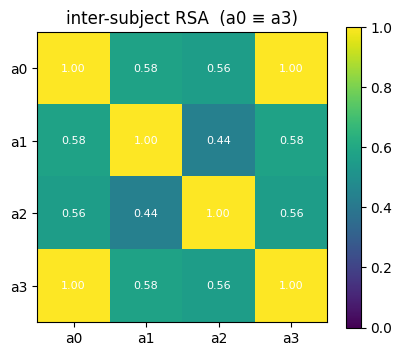

In [4]:
rdms = [1 - np.corrcoef(R) for R in reps]
def rsa(a, b):
    iu = np.triu_indices_from(a, k=1)
    return float(np.corrcoef(a[iu], b[iu])[0, 1])
M = np.array([[rsa(rdms[i], rdms[j]) for j in range(N)] for i in range(N)])
print('agent0 vs agent3 (same seed): %.3f  (control ~1.0)' % M[0, 3])
print('agent0 vs agent1 (diff seed): %.3f' % M[0, 1])
fig, ax = plt.subplots(figsize=(4.2, 3.6))
im = ax.imshow(M, cmap='viridis', vmin=0, vmax=1)
ax.set_xticks(range(N)); ax.set_yticks(range(N))
ax.set_xticklabels([f'a{i}' for i in range(N)]); ax.set_yticklabels([f'a{i}' for i in range(N)])
for i in range(N):
    for j in range(N):
        ax.text(j, i, f'{M[i,j]:.2f}', ha='center', va='center', color='w', fontsize=8)
fig.colorbar(im); ax.set_title('inter-subject RSA  (a0 \u2261 a3)'); plt.tight_layout(); plt.show()

## The interaction harness — one subject's action feeds the next

`multi_agent_rollout` runs turn-taking: each agent observes (via the mediator), acts, and its action becomes the next agent's input.

In [5]:
transcript = multi_agent_rollout(agents, DialogueMediator(task='pass the signal'), n_turns=3)
fired = sorted(set(t['agent'] for t in transcript))
print('rollout: %d turn-entries across %d subjects: %s' % (len(transcript), len(fired), fired))

rollout: 12 turn-entries across 4 subjects: ['agent0', 'agent1', 'agent2', 'agent3']


## The other *N*: biological subjects in the data

Distinct from N model-subjects, the neural benchmarks already handle **N biological subjects** in the target data via leave-one-subject-out cross-validation (e.g., 10 subjects in Lahner2024, 4 in Algonauts). Same word, different axis — one is how many models you compare, the other is how many brains the data came from.

**Demonstrated:** N model-subjects run through one interface — their representations compared by inter-subject RSA (the same-seed control recovers 1.0), and their actions chained through the multi-agent harness. The data-side N (biological subjects) is a separate axis handled by leave-one-subject-out CV.